In [8]:
import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from pandas.tseries.offsets import QuarterEnd


In [9]:
def fetch_data_fmp(ticker, api_key):
    url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={api_key}"
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"Request failed with status code {response.status_code}")
    data = response.json()
    if "historical" not in data or not isinstance(data["historical"], list):
        raise ValueError(f"Unexpected response for {ticker}: {data}")
    records = data["historical"]
    if len(records) == 0:
        raise ValueError(f"No daily data returned for {ticker}.")
    df = pd.DataFrame(records)
    df = df[["date", "open", "high", "low", "close", "volume"]]
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df.set_index("date", inplace=True)
    return df


In [10]:
def compute_indicators(df):
    df = df.rename(columns={
        'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'
    })
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    roll_up = gain.ewm(span=14).mean()
    roll_down = loss.ewm(span=14).mean()
    rs = roll_up / roll_down
    df['RSI'] = 100.0 - (100.0 / (1.0 + rs))
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD'] = macd
    df['MACD_Signal'] = signal
    df['MACD_Hist'] = macd - signal
    sma = df['Close'].rolling(window=20).mean()
    std = df['Close'].rolling(window=20).std()
    df['BB_Mid'] = sma
    df['BB_Upper'] = sma + 2 * std
    df['BB_Lower'] = sma - 2 * std
    df['Return_1D'] = df['Close'].pct_change().shift(-1)
    df.dropna(inplace=True)
    return df


In [11]:
def prepare_data_quarterly_minmax(df, feature_cols, target_col='Return_1D', window_size=60):
    df = df.copy()
    df['Quarter'] = df.index.to_period('Q')
    
    scaled_chunks = []
    scalers = {}
    
    for quarter, group in df.groupby('Quarter'):
        chunk = group[feature_cols + [target_col]].copy()
        if len(chunk) < window_size:
            continue
        scaler = MinMaxScaler()
        scaled_values = scaler.fit_transform(chunk)
        scaled_chunk = pd.DataFrame(scaled_values, columns=feature_cols + [target_col], index=chunk.index)
        scaled_chunks.append(scaled_chunk)
        scalers[str(quarter)] = scaler

    df_scaled = pd.concat(scaled_chunks).sort_index()
    df_scaled.dropna(inplace=True)

    data = df_scaled[feature_cols].values
    target = df_scaled[target_col].values
    X, y = [], []
    for i in range(window_size, len(df_scaled)):
        X.append(data[i - window_size:i])
        y.append(target[i])
    
    return np.array(X), np.array(y), scalers, df_scaled


In [12]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=50, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


In [13]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None or self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


In [ ]:
API_KEY = ""
TICKER = "AAPL"
WINDOW_SIZE = 30
EPOCHS = 40
BATCH_SIZE = 32
LR = 1e-3
HIDDEN_DIM = 100
NUM_LAYERS = 2
DROPOUT = 0.2
PATIENCE = 10
FINAL_HOLDOUT_SIZE = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = fetch_data_fmp(TICKER, API_KEY)
df = compute_indicators(df)

feature_cols = ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']
X, y, scalers, df_scaled = prepare_data_quarterly_minmax(df, feature_cols, target_col='Return_1D', window_size=WINDOW_SIZE)

Using device: cuda
Epoch 1, Train Loss: 0.116426, Val Loss: 0.053912
Epoch 2, Train Loss: 0.057573, Val Loss: 0.049387
Epoch 3, Train Loss: 0.055752, Val Loss: 0.048595
Epoch 4, Train Loss: 0.055090, Val Loss: 0.048177
Epoch 5, Train Loss: 0.055816, Val Loss: 0.049778
Epoch 6, Train Loss: 0.054407, Val Loss: 0.050515
Epoch 7, Train Loss: 0.056338, Val Loss: 0.048459
Epoch 8, Train Loss: 0.054942, Val Loss: 0.047823
Epoch 9, Train Loss: 0.054836, Val Loss: 0.052790
Epoch 10, Train Loss: 0.054786, Val Loss: 0.048236
Epoch 11, Train Loss: 0.054062, Val Loss: 0.047517
Epoch 12, Train Loss: 0.054462, Val Loss: 0.047580
Epoch 13, Train Loss: 0.054333, Val Loss: 0.048527
Epoch 14, Train Loss: 0.053760, Val Loss: 0.049483
Epoch 15, Train Loss: 0.054718, Val Loss: 0.048048
Epoch 16, Train Loss: 0.053816, Val Loss: 0.048202
Epoch 17, Train Loss: 0.054048, Val Loss: 0.047625
Epoch 18, Train Loss: 0.053257, Val Loss: 0.047846
Epoch 19, Train Loss: 0.053449, Val Loss: 0.047767
Epoch 20, Train Loss:

In [ ]:
split_point = len(X) - FINAL_HOLDOUT_SIZE
X_train_all, y_train_all = X[:split_point], y[:split_point]
X_test_final, y_test_final = X[split_point:], y[split_point:]

train_dataset = StockDataset(X_train_all, y_train_all)
test_dataset = StockDataset(X_test_final, y_test_final)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = LSTMModel(input_dim=X.shape[2], hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
stopper = EarlyStopping(patience=PATIENCE)

train_losses = []
val_losses = []

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.float().to(device), y_batch.float().to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.float().to(device), y_batch.float().to(device)
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    stopper(val_loss)
    if stopper.should_stop:
        print("Early stopping triggered.")
        break

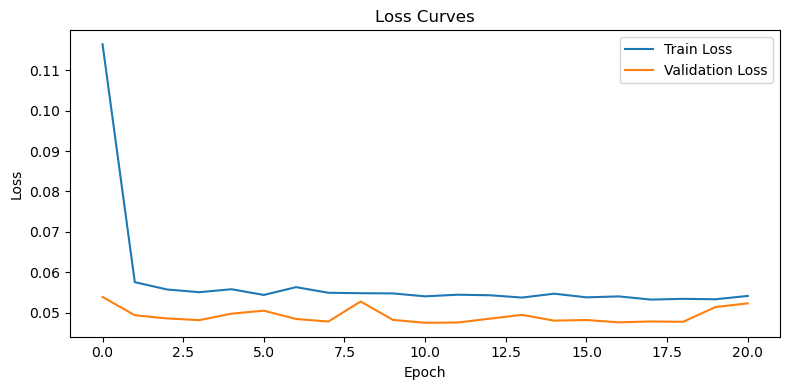

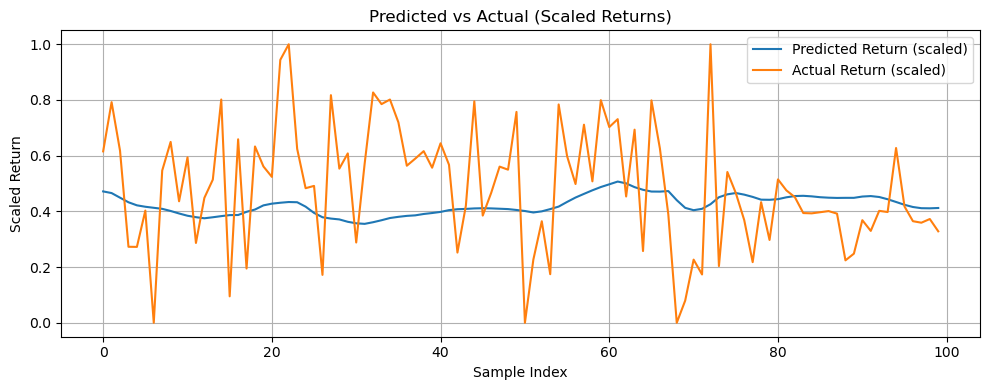

In [15]:
# Plot losses
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Predict
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_final).float().to(device)
    preds = model(X_test_tensor).cpu().numpy().ravel()

# Since MinMax scaling was done per quarter, we can’t do an exact inverse unless we map each prediction back
# Instead, we show scaled values directly
df_result = pd.DataFrame({
    "Predicted Return (scaled)": preds,
    "Actual Return (scaled)": y_test_final
})

df_result.plot(figsize=(10, 4), title="Predicted vs Actual (Scaled Returns)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Return")
plt.grid(True)
plt.tight_layout()
plt.show()
